# New production defaults against the first DR2 run

- Same 187 galaxies, same manifest, same seeds.
- New run frees the Kriek & Conroy dust index.
- New run uses a StudentT continuity prior.
- Everything else is unchanged.

In [1]:
import json
import sys
from pathlib import Path

import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

NEW_ROOT = Path.cwd().resolve()
assert NEW_ROOT.name == "dr2-quiescent-new-defaults"
PROJECT_ROOT = NEW_ROOT.parents[1]
OLD_ROOT = PROJECT_ROOT / "results/rtx-5060-dr2-quiescent-full-spectrum"
FIGURE_DIR = NEW_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from spectral_figures import mark_absorption_features  # noqa: E402

BLUE, ORANGE, GREEN, GREY = "#0072B2", "#E69F00", "#009E73", "#999999"
rcParams.update({
    "font.size": 9, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True, "savefig.dpi": 150,
})

## Load both summary tables

- One row per galaxy, joined on object id.

In [2]:
old = pd.read_csv(PROJECT_ROOT / "results/dr2-quiescent-summary.csv")
new = pd.read_csv(PROJECT_ROOT / "results/dr2-quiescent-new-defaults-summary.csv")
assert len(old) == len(new) == 187
pair = old.merge(new, on="object_id", suffixes=("_old", "_new"), validate="one_to_one")
assert len(pair) == 187
assert (pair["seed_old"] == pair["seed_new"]).all()
print(f"joined {len(pair)} galaxies on identical seeds")

joined 187 galaxies on identical seeds


## Per-galaxy shifts

- Half-width is the mean 16-84 half-interval of both runs.
- A shift beyond one half-width is a real move.

In [3]:
PARAMS = [
    ("age", r"$t_{\mathrm{MW}}$ [Gyr]"),
    ("logZ_abs", r"$\log_{10} Z$"),
    ("alpha_fe", r"$[\alpha/\mathrm{Fe}]$"),
    ("tau_dust", r"$\tau_{\mathrm{diffuse}}$"),
    ("logmass", r"$\log_{10}(M_\star/M_\odot)$"),
]


def shift_table(frame, params):
    rows = []
    for name, _ in params:
        shift = frame[f"{name}_q50_new"] - frame[f"{name}_q50_old"]
        half = 0.5 * (
            0.5 * (frame[f"{name}_q84_old"] - frame[f"{name}_q16_old"])
            + 0.5 * (frame[f"{name}_q84_new"] - frame[f"{name}_q16_new"])
        )
        rows.append({
            "parameter": name,
            "median shift": float(np.median(shift)),
            "NMAD shift": float(1.4826 * np.median(np.abs(shift - np.median(shift)))),
            "median half-width": float(np.median(half)),
            "moved > 1 half-width": int((np.abs(shift) > half).sum()),
        })
    return pd.DataFrame(rows)


shifts = shift_table(pair, PARAMS)
display(shifts)

,parameter,median shift,NMAD shift,median half-width,moved > 1 half-width
0,age,1.229449,1.147397,0.174641,169
1,logZ_abs,-0.167231,0.214941,0.035817,173
2,alpha_fe,-0.056207,0.058658,0.018209,148
3,tau_dust,0.169182,0.145090,0.022587,171
4,logmass,0.190239,0.116139,0.018009,182


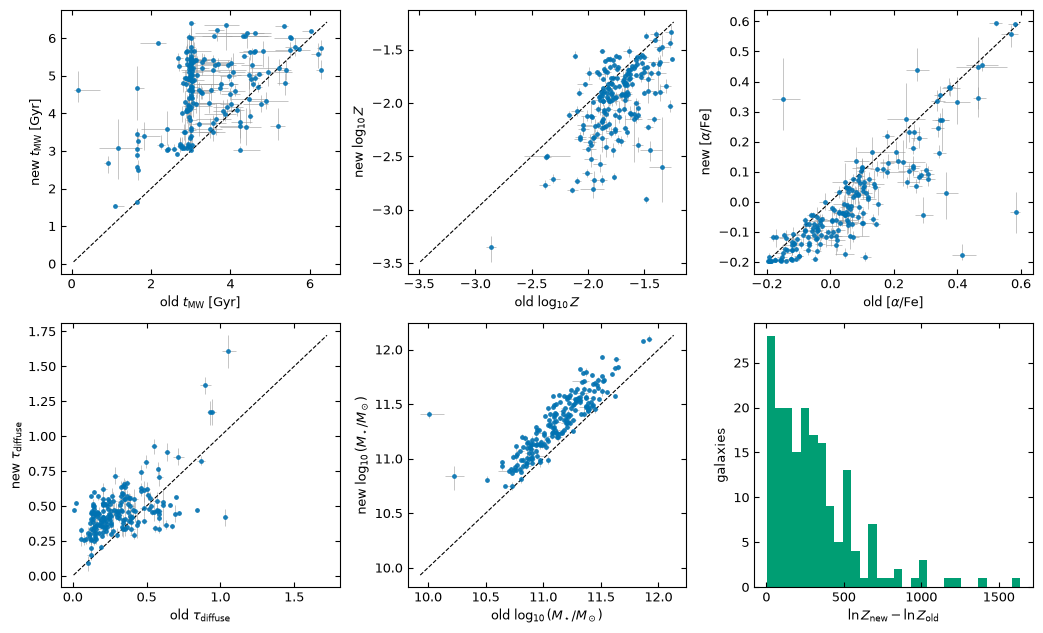

median ln Z shift 254.28; new higher for 187/187


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.4))
for axis, (name, label) in zip(axes.ravel(), PARAMS):
    axis.errorbar(
        pair[f"{name}_q50_old"], pair[f"{name}_q50_new"],
        xerr=[pair[f"{name}_q50_old"] - pair[f"{name}_q16_old"],
              pair[f"{name}_q84_old"] - pair[f"{name}_q50_old"]],
        yerr=[pair[f"{name}_q50_new"] - pair[f"{name}_q16_new"],
              pair[f"{name}_q84_new"] - pair[f"{name}_q50_new"]],
        fmt="o", ms=2.5, lw=0.5, color=BLUE, ecolor=GREY, alpha=0.8,
    )
    lo = min(pair[f"{name}_q16_old"].min(), pair[f"{name}_q16_new"].min())
    hi = max(pair[f"{name}_q84_old"].max(), pair[f"{name}_q84_new"].max())
    axis.plot([lo, hi], [lo, hi], color="k", lw=0.8, ls="--")
    axis.set(xlabel=f"old {label}", ylabel=f"new {label}")
lnz_shift = pair["lnZ_new"] - pair["lnZ_old"]
axes.ravel()[5].hist(lnz_shift, bins=30, color=GREEN)
axes.ravel()[5].set(xlabel=r"$\ln Z_{\mathrm{new}} - \ln Z_{\mathrm{old}}$", ylabel="galaxies")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "old-vs-new-parameters.png", bbox_inches="tight")
plt.show()
print(f"median ln Z shift {np.median(lnz_shift):.2f}; new higher for {(lnz_shift > 0).sum()}/187")

## Dust index posteriors

- Old run pinned the slope at -0.7.
- New run samples it on Uniform(-1.0, 0.4).

In [5]:
def weighted_quantiles(values, log_weights, quantiles=(0.16, 0.50, 0.84)):
    weights = np.exp(log_weights - log_weights.max())
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return np.interp(quantiles, cumulative, values)


manifest = json.loads((NEW_ROOT / "targets.json").read_text())
dust_rows = []
for target in manifest["targets"]:
    folder = NEW_ROOT / f"{target['object_id']}-{target['spect_id']}"
    with h5py.File(folder / "ceridwen_result.h5", "r") as handle:
        draws = handle["samples/diffuse_dust_index"][:]
        log_weights = handle["samples/log_weights"][:]
    q16, q50, q84 = weighted_quantiles(draws, log_weights)
    dust_rows.append({
        "object_id": target["object_id"], "dust_index_q16": q16,
        "dust_index_q50": q50, "dust_index_q84": q84,
    })
dust = pd.DataFrame(dust_rows)
dust.to_csv(NEW_ROOT / "dust_index_posteriors.csv", index=False)
# Railing means the lower credible edge sits on the Uniform(-1.0, 0.4) prior floor.
railed = dust["dust_index_q16"] < -0.98
print(f"median dust index {dust['dust_index_q50'].median():.3f}")
print(f"railing at the -1.0 prior edge: {int(railed.sum())}/187")
print(f"median posterior below the old fixed -0.7: {int((dust['dust_index_q50'] < -0.7).sum())}/187")

median dust index -0.942
railing at the -1.0 prior edge: 99/187
median posterior below the old fixed -0.7: 121/187


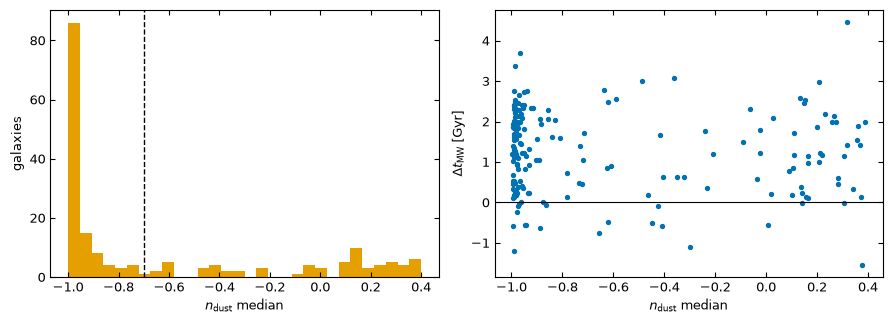

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3))
axes[0].hist(dust["dust_index_q50"], bins=30, range=(-1.0, 0.4), color=ORANGE)
axes[0].axvline(-0.7, color="k", ls="--", lw=1)
axes[0].set(xlabel=r"$n_{\mathrm{dust}}$ median", ylabel="galaxies")
merged = pair.merge(dust, on="object_id")
axes[1].scatter(merged["dust_index_q50"], merged["age_q50_new"] - merged["age_q50_old"],
                s=8, color=BLUE)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(xlabel=r"$n_{\mathrm{dust}}$ median", ylabel=r"$\Delta t_{\mathrm{MW}}$ [Gyr]")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "dust-index-posteriors.png", bbox_inches="tight")
plt.show()

## Age-redshift headline against Borghi+22

- Borghi bins: sigma split 215 km/s, four fixed z bins.
- Uncertainty is NMAD divided by sqrt(N).

In [7]:
SIGMA_SPLIT, Z_EDGES = 215.0, np.array([0.6, 0.675, 0.75, 0.825, 0.9])
BORGHI_PATH = PROJECT_ROOT / (
    "data/processed/borghi2022_legac_dr2/"
    "borghi2022_legac_dr2_spectrum_matches copy.tsv"
)
borghi = pd.read_csv(BORGHI_PATH, sep="\t", comment="#")
best = borghi.sort_values("dr2_sn_per_pixel").drop_duplicates("mms2013_id", keep="last")


def add_bands(frame):
    out = frame.copy()
    out["group"] = np.where(out["sigma_star_kms"] > SIGMA_SPLIT, "high sigma", "low sigma")
    out["zbin"] = pd.cut(out["z"], Z_EDGES, labels=[1, 2, 3, 4], include_lowest=True)
    return out


def binned_median(frame, value):
    rows = []
    for (group, zbin), members in add_bands(frame).dropna(subset=["zbin"]).groupby(
        ["group", "zbin"], observed=True
    ):
        values = members[value].to_numpy()
        median = float(np.median(values))
        rows.append({
            "group": group, "zbin": zbin, "z": float(members["z"].median()),
            "median": median,
            "err": 1.4826 * float(np.median(np.abs(values - median))) / np.sqrt(len(values)),
            "n": len(values),
        })
    return pd.DataFrame(rows)


overlap_old = old.merge(best[["mms2013_id", "borghi_age_gyr"]],
                        left_on="object_id", right_on="mms2013_id")
binned_borghi = binned_median(overlap_old, "borghi_age_gyr")
print(f"Borghi overlap: {len(overlap_old)} galaxies")

Borghi overlap: 68 galaxies


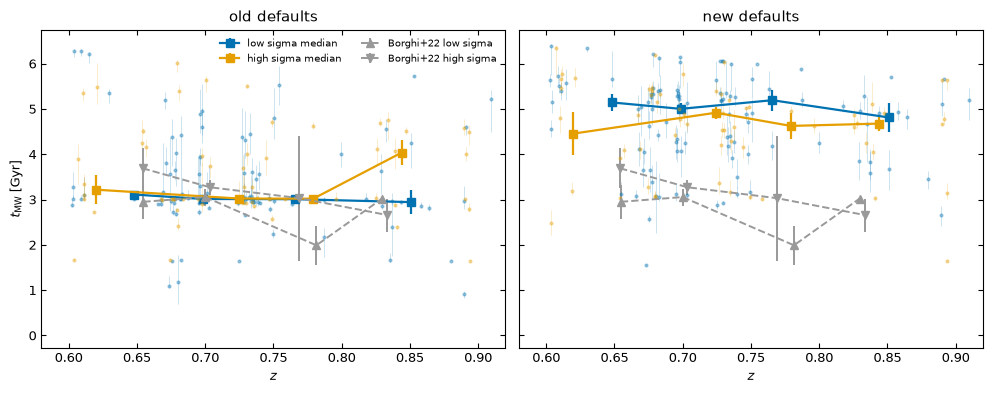

old: mean median-age offset from Borghi +0.21 Gyr
new: mean median-age offset from Borghi +1.89 Gyr


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
for axis, (frame, title) in zip(axes, [(old, "old defaults"), (new, "new defaults")]):
    banded = add_bands(frame)
    for group, color in [("low sigma", BLUE), ("high sigma", ORANGE)]:
        members = banded[banded["group"] == group]
        axis.errorbar(members["z"], members["age_q50"],
                      yerr=[members["age_q50"] - members["age_q16"],
                            members["age_q84"] - members["age_q50"]],
                      fmt="o", ms=2.0, lw=0.4, alpha=0.35, color=color)
        bins = binned_median(frame, "age_q50")
        bins = bins[bins["group"] == group]
        axis.errorbar(bins["z"], bins["median"], yerr=bins["err"], fmt="s-", ms=6,
                      lw=1.6, color=color, label=f"{group} median")
    for group, marker in [("low sigma", "^"), ("high sigma", "v")]:
        bins = binned_borghi[binned_borghi["group"] == group]
        axis.errorbar(bins["z"], bins["median"], yerr=bins["err"], fmt=marker + "--",
                      ms=6, lw=1.4, color=GREY, label=f"Borghi+22 {group}")
    axis.set(xlabel=r"$z$", title=title, xlim=(0.58, 0.92))
axes[0].set_ylabel(r"$t_{\mathrm{MW}}$ [Gyr]")
axes[0].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "headline-age-redshift-old-vs-new.png", bbox_inches="tight")
plt.show()
for label, frame in [("old", old), ("new", new)]:
    bins = binned_median(frame, "age_q50")
    joined = bins.merge(binned_borghi, on=["group", "zbin"], suffixes=("", "_borghi"))
    print(f"{label}: mean median-age offset from Borghi "
          f"{(joined['median'] - joined['median_borghi']).mean():+.2f} Gyr")

## Oldest 30% per bin

- Chronometer cut: keep the oldest 30% of each sigma-z bin.
- Same bins, same Borghi+22 treatment.
- Full-median figure above is unchanged.

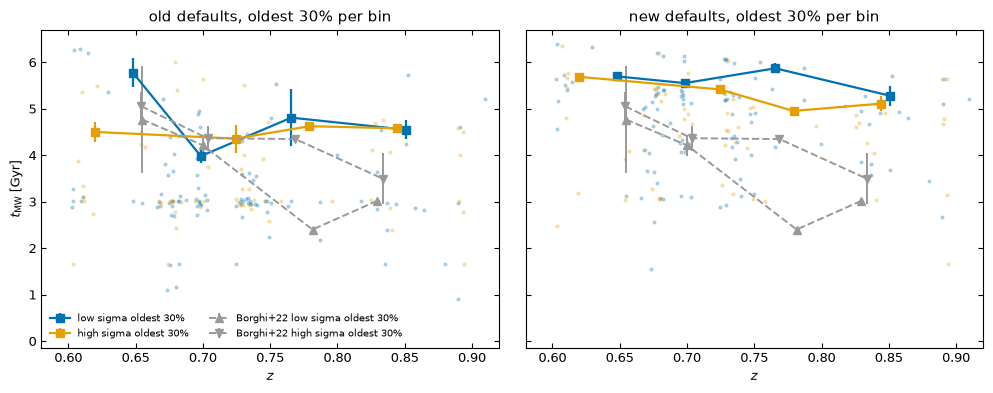

,run,group,mean offset from Borghi [Gyr],d age / d z [Gyr],galaxies per bin
0,old,high sigma,0.200180,0.560104,1
1,old,low sigma,1.178751,-3.615103,3
2,new,high sigma,0.975915,-3.023970,1
3,new,low sigma,1.998947,-1.535460,3


In [9]:
OLDEST_FRACTION = 0.3


def binned_oldest_median(frame, value, fraction=OLDEST_FRACTION):
    rows = []
    for (group, zbin), members in add_bands(frame).dropna(subset=["zbin"]).groupby(
        ["group", "zbin"], observed=True
    ):
        values = np.sort(members[value].to_numpy())
        keep = max(int(np.ceil(fraction * len(values))), 1)
        oldest = values[-keep:]
        median = float(np.median(oldest))
        rows.append({
            "group": group, "zbin": zbin, "z": float(members["z"].median()),
            "median": median,
            "err": 1.4826 * float(np.median(np.abs(oldest - median))) / np.sqrt(keep),
            "n": keep,
        })
    return pd.DataFrame(rows)


oldest_borghi = binned_oldest_median(overlap_old, "borghi_age_gyr")
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
for axis, (frame, title) in zip(axes, [(old, "old defaults"), (new, "new defaults")]):
    banded = add_bands(frame)
    for group, color in [("low sigma", BLUE), ("high sigma", ORANGE)]:
        members = banded[banded["group"] == group]
        axis.scatter(members["z"], members["age_q50"], s=4, alpha=0.25, color=color)
        bins = binned_oldest_median(frame, "age_q50")
        bins = bins[bins["group"] == group]
        axis.errorbar(bins["z"], bins["median"], yerr=bins["err"], fmt="s-", ms=6,
                      lw=1.6, color=color, label=f"{group} oldest 30%")
    for group, marker in [("low sigma", "^"), ("high sigma", "v")]:
        bins = oldest_borghi[oldest_borghi["group"] == group]
        axis.errorbar(bins["z"], bins["median"], yerr=bins["err"], fmt=marker + "--",
                      ms=6, lw=1.4, color=GREY, label=f"Borghi+22 {group} oldest 30%")
    axis.set(xlabel=r"$z$", title=f"{title}, oldest 30% per bin", xlim=(0.58, 0.92))
axes[0].set_ylabel(r"$t_{\mathrm{MW}}$ [Gyr]")
axes[0].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "headline-age-redshift-oldest30.png", bbox_inches="tight")
plt.show()
oldest_rows = []
for label, frame in [("old", old), ("new", new)]:
    bins = binned_oldest_median(frame, "age_q50")
    joined = bins.merge(oldest_borghi, on=["group", "zbin"], suffixes=("", "_borghi"))
    for group, part in joined.groupby("group"):
        slope = np.polyfit(part["z"], part["median"], 1)[0]
        oldest_rows.append({
            "run": label, "group": group,
            "mean offset from Borghi [Gyr]": float((part["median"] - part["median_borghi"]).mean()),
            "d age / d z [Gyr]": float(slope),
            "galaxies per bin": int(part["n"].min()),
        })
oldest_table = pd.DataFrame(oldest_rows)
oldest_table.to_csv(NEW_ROOT / "age_redshift_oldest30.csv", index=False)
display(oldest_table)

## Fits, star-formation histories and corners

- Four galaxies spanning the age-shift range.

In [10]:
shift_age = (pair["age_q50_new"] - pair["age_q50_old"]).to_numpy()
order = np.argsort(shift_age)
picks = pair.iloc[[order[0], order[len(order) // 3], order[2 * len(order) // 3], order[-1]]]
picks = picks[["object_id", "spect_id_new", "age_q50_old", "age_q50_new"]]
display(picks)

,object_id,spect_id_new,age_q50_old,age_q50_new
71,139662,M2_139662,5.206391,3.662380
50,120540,M3_120540,2.825372,3.511694
163,237437,M6_237437,3.073855,4.895063
29,104877,M14_104877,0.172735,4.630593


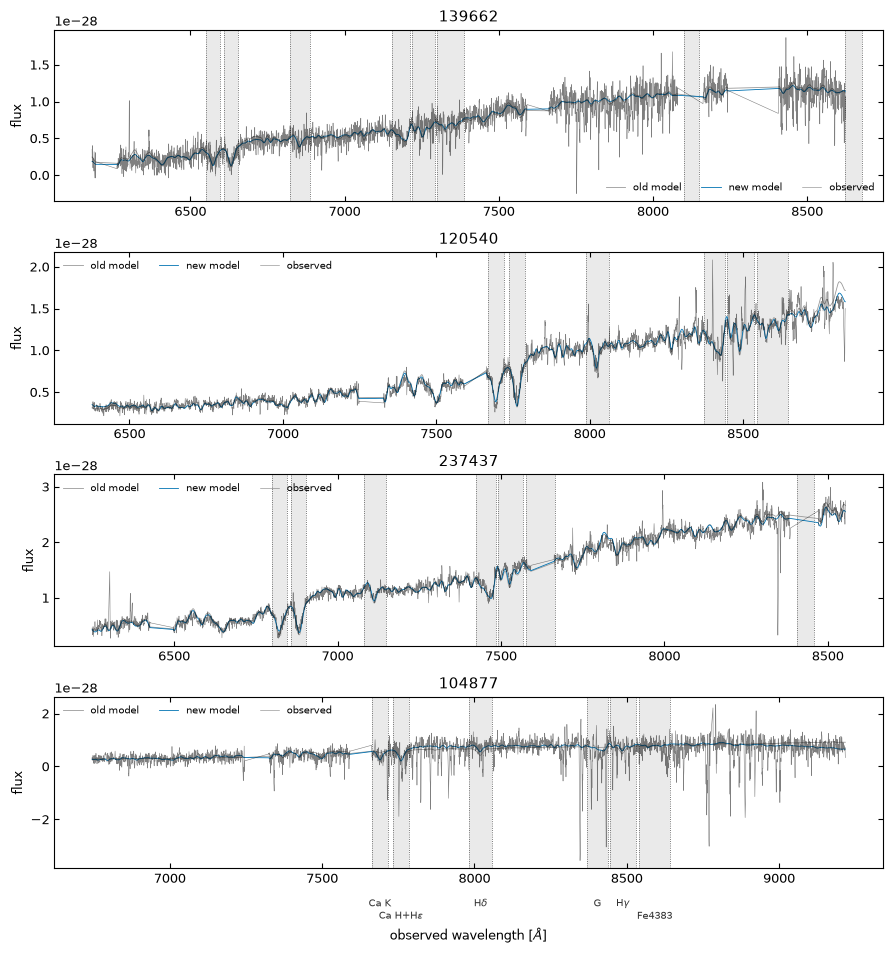

In [11]:
def target_folders(object_id, spect_id):
    return (OLD_ROOT / f"{object_id}-{spect_id}", NEW_ROOT / f"{object_id}-{spect_id}")


fig, axes = plt.subplots(len(picks), 1, figsize=(9.0, 2.4 * len(picks)), sharex=False)
for axis, row in zip(np.atleast_1d(axes), picks.itertuples(index=False)):
    old_dir, new_dir = target_folders(row.object_id, row.spect_id_new)
    for folder, color, label in [(old_dir, GREY, "old"), (new_dir, BLUE, "new")]:
        with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as handle:
            wave = handle["spectrum/wavelength"][:]
            mask = handle["spectrum/mask"][:]
            model = handle["spectrum/posterior_q50"][:]
            observed = handle["spectrum/observed"][:]
            zred = float(handle.attrs["redshift"])
        axis.plot(wave[mask], model[mask], color=color, lw=0.6, label=f"{label} model")
    axis.plot(wave[mask], observed[mask], color="k", lw=0.4, alpha=0.5, label="observed")
    axis.set(ylabel="flux", title=f"{row.object_id}")
    axis.legend(frameon=False, fontsize=7, ncol=3)
    bottom = axis is np.atleast_1d(axes)[-1]
    mark_absorption_features(
        axis, zred, show_labels=bottom,
        xlabel=r"observed wavelength [$\AA$]" if bottom else None)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "example-fits.png", bbox_inches="tight")
plt.show()

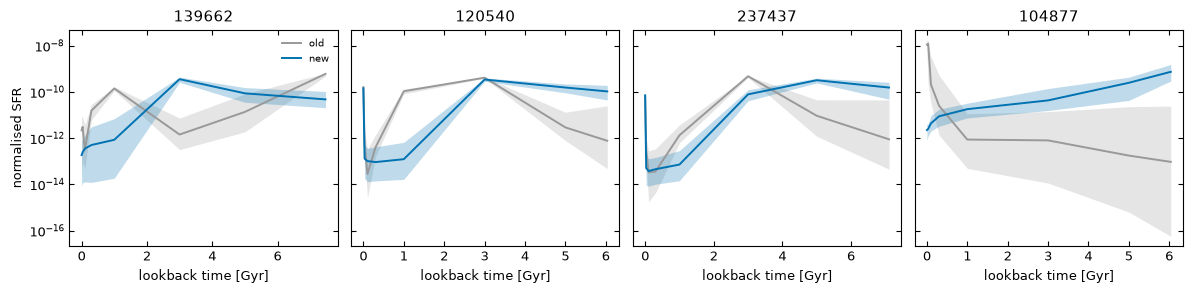

In [12]:
fig, axes = plt.subplots(1, len(picks), figsize=(3.0 * len(picks), 3.0), sharey=True)
for axis, row in zip(np.atleast_1d(axes), picks.itertuples(index=False)):
    old_dir, new_dir = target_folders(row.object_id, row.spect_id_new)
    for folder, color, label in [(old_dir, GREY, "old"), (new_dir, BLUE, "new")]:
        with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as handle:
            lookback = handle["sfh/lookback_time_gyr"][:]
            q16 = handle["sfh/normalized_sfr_q16"][:]
            q50 = handle["sfh/normalized_sfr_q50"][:]
            q84 = handle["sfh/normalized_sfr_q84"][:]
        axis.plot(lookback, q50, color=color, lw=1.4, label=label)
        axis.fill_between(lookback, q16, q84, color=color, alpha=0.25, lw=0)
    axis.set(xlabel=r"lookback time [Gyr]", title=f"{row.object_id}", yscale="log")
np.atleast_1d(axes)[0].set_ylabel(r"normalised SFR")
np.atleast_1d(axes)[0].legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "example-sfh.png", bbox_inches="tight")
plt.show()

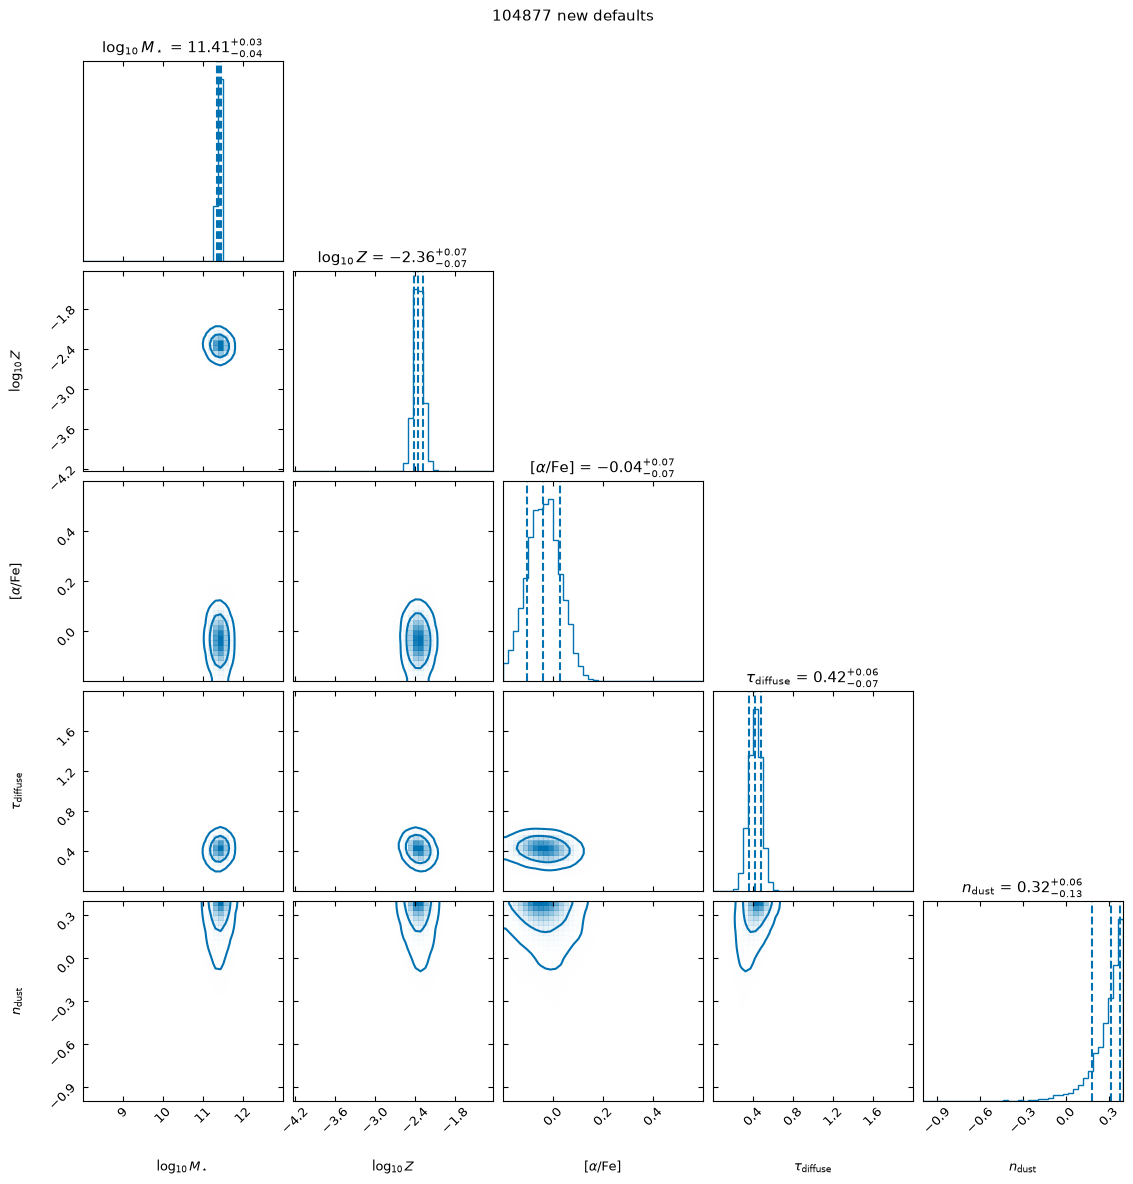

In [13]:
CORNER_PARAMS = ["logmass", "Z", "afe", "diffuse_tau_kc", "diffuse_dust_index"]
CORNER_LABELS = [r"$\log_{10} M_\star$", r"$\log_{10} Z$", r"$[\alpha/\mathrm{Fe}]$",
                 r"$\tau_{\mathrm{diffuse}}$", r"$n_{\mathrm{dust}}$"]
example = picks.iloc[-1]
new_dir = NEW_ROOT / f"{example.object_id}-{example.spect_id_new}"
with h5py.File(new_dir / "ceridwen_result.h5", "r") as handle:
    log_weights = handle["samples/log_weights"][:]
    columns = np.column_stack([handle[f"samples/{name}"][:] for name in CORNER_PARAMS])
weights = np.exp(log_weights - log_weights.max())
figure = corner.corner(columns, labels=CORNER_LABELS, weights=weights,
                       quantiles=[0.16, 0.50, 0.84], show_titles=True,
                       levels=(0.68, 0.95), bins=40, color=BLUE, smooth=1.2,
                       plot_datapoints=False, fill_contours=False)
figure.suptitle(f"{example.object_id} new defaults", y=1.01)
figure.savefig(FIGURE_DIR / "example-corner.png", bbox_inches="tight")
plt.show()